
================ PEM CHARGE / DISCHARGE SUMMARY ================

                Metric       Value  Unit
    Total charge input   50.535007   mAh
   Total charge output   11.523472   mAh
Current-counting ratio   22.802950     %
    Total energy input   81.798611   mWh
   Total energy output    0.000000   mWh
          Energy ratio    0.000000     %
           Max voltage    1.507500     V
           Min voltage    0.000000     V
           Max current  178.500000    mA
           Min current -119.475000    mA
             Max power  269.375000    mW
             Min power    0.000000    mW
         Test duration    0.511389 hours


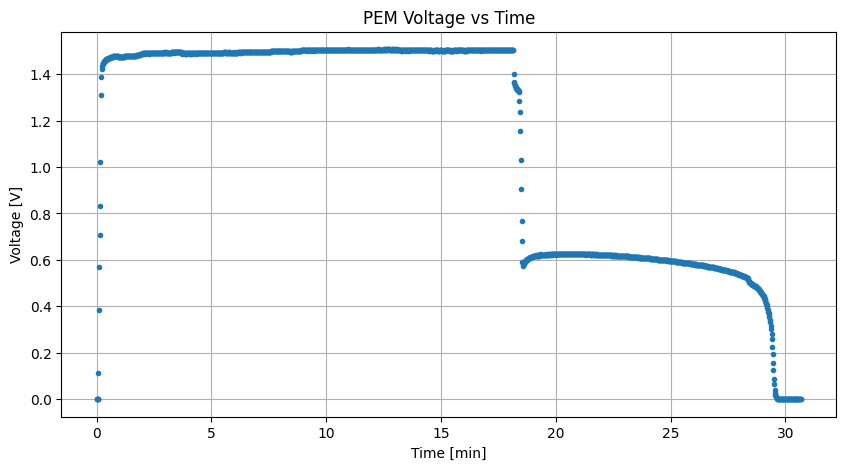

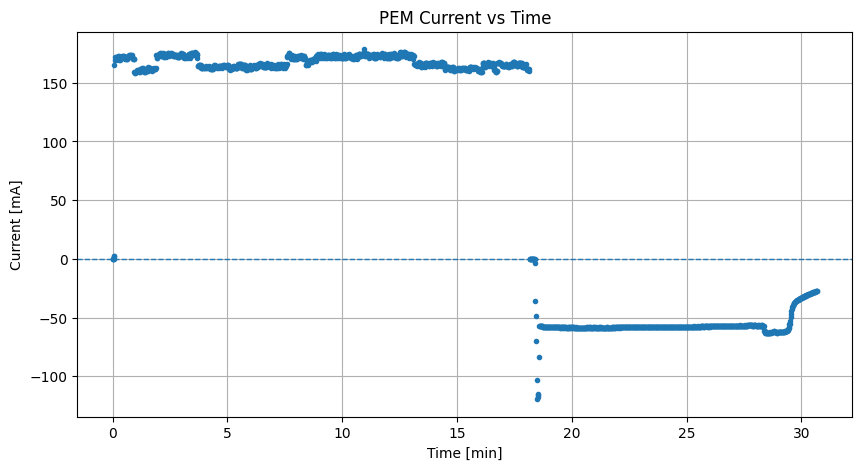

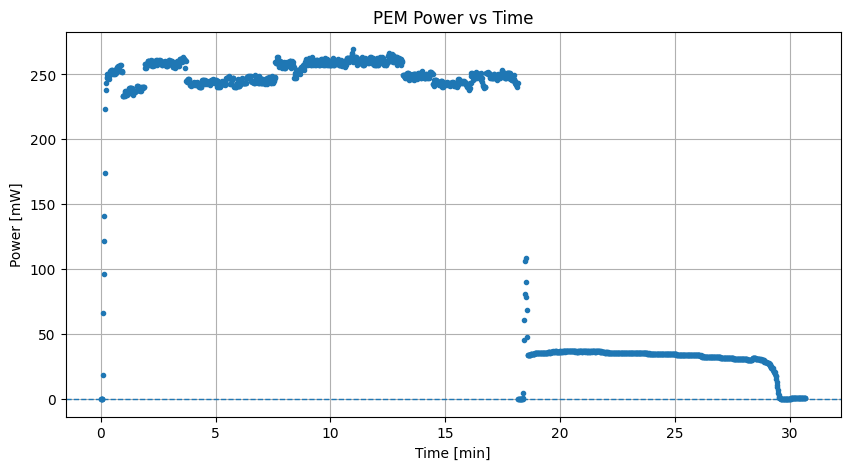

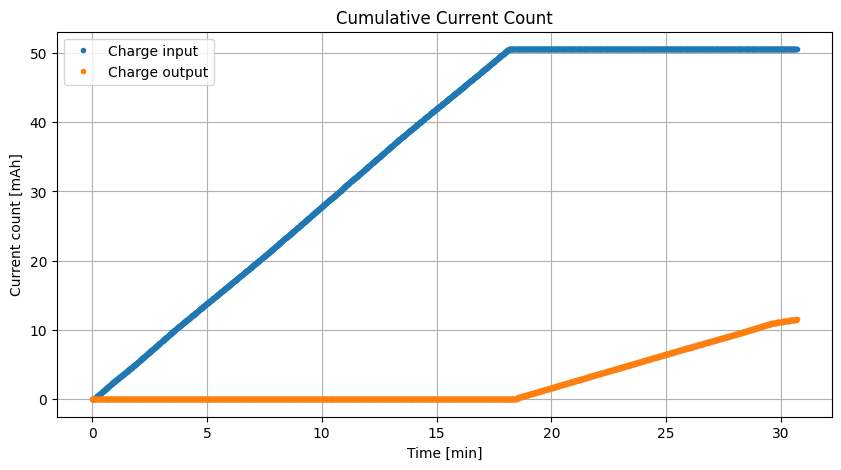

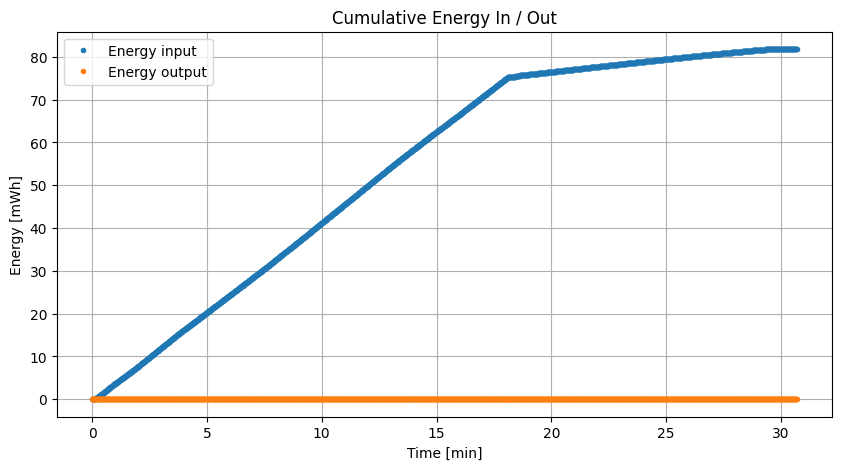

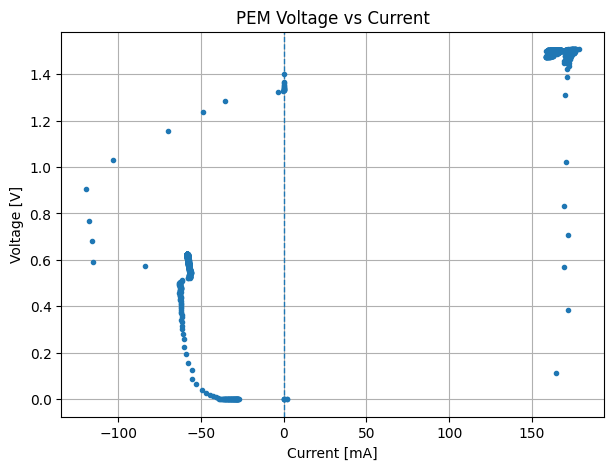

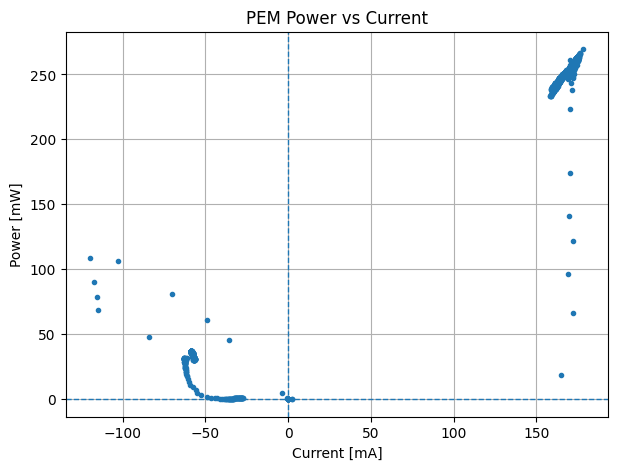

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

CSV_FILE = "discharge_PEM_full.csv"

V_COL = "ina4_bus_V"
I_COL = "ina4_current_mA"
P_COL = "ina4_power_mW"
TIME_COL = "timestamp"

# If your signs are reversed, set this to True
REVERSE_SIGN = False

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(CSV_FILE)

# Convert timestamp to datetime
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")

# Keep only rows with valid time and INA4 values
df = df.dropna(subset=[TIME_COL, V_COL, I_COL, P_COL]).copy()

# Sort by time
df = df.sort_values(TIME_COL).reset_index(drop=True)

# Convert to seconds from start
df["time_s"] = (df[TIME_COL] - df[TIME_COL].iloc[0]).dt.total_seconds()
df["time_min"] = df["time_s"] / 60
df["time_h"] = df["time_s"] / 3600

# Convert units
df["voltage_V"] = df[V_COL]
df["current_A"] = df[I_COL] / 1000
df["power_W"] = df[P_COL] / 1000

if REVERSE_SIGN:
    df["current_A"] *= -1
    df["power_W"] *= -1

# Time difference between samples
df["dt_s"] = df["time_s"].diff().fillna(0)

# Remove strange negative or very large time jumps if present
df.loc[df["dt_s"] < 0, "dt_s"] = 0

# ============================================================
# CURRENT COUNTING AND ENERGY CALCULATION
# ============================================================

# Positive values = charging / energy into PEM cell
df["current_in_A"] = df["current_A"].clip(lower=0)
df["power_in_W"] = df["power_W"].clip(lower=0)

# Negative values = discharging / energy extracted from PEM cell
df["current_out_A"] = (-df["current_A"].clip(upper=0))
df["power_out_W"] = (-df["power_W"].clip(upper=0))

# Charge in Ah and mAh
df["charge_in_Ah_step"] = df["current_in_A"] * df["dt_s"] / 3600
df["charge_out_Ah_step"] = df["current_out_A"] * df["dt_s"] / 3600

df["charge_in_mAh_cum"] = df["charge_in_Ah_step"].cumsum() * 1000
df["charge_out_mAh_cum"] = df["charge_out_Ah_step"].cumsum() * 1000

# Energy in Wh and mWh
df["energy_in_Wh_step"] = df["power_in_W"] * df["dt_s"] / 3600
df["energy_out_Wh_step"] = df["power_out_W"] * df["dt_s"] / 3600

df["energy_in_mWh_cum"] = df["energy_in_Wh_step"].cumsum() * 1000
df["energy_out_mWh_cum"] = df["energy_out_Wh_step"].cumsum() * 1000

# Total values
total_charge_in_mAh = df["charge_in_Ah_step"].sum() * 1000
total_charge_out_mAh = df["charge_out_Ah_step"].sum() * 1000

total_energy_in_mWh = df["energy_in_Wh_step"].sum() * 1000
total_energy_out_mWh = df["energy_out_Wh_step"].sum() * 1000

# Efficiencies / ratios
coulomb_ratio_pct = 100 * total_charge_out_mAh / total_charge_in_mAh if total_charge_in_mAh > 0 else np.nan
energy_ratio_pct = 100 * total_energy_out_mWh / total_energy_in_mWh if total_energy_in_mWh > 0 else np.nan

# ============================================================
# SUMMARY
# ============================================================

summary = pd.DataFrame({
    "Metric": [
        "Total charge input",
        "Total charge output",
        "Current-counting ratio",
        "Total energy input",
        "Total energy output",
        "Energy ratio",
        "Max voltage",
        "Min voltage",
        "Max current",
        "Min current",
        "Max power",
        "Min power",
        "Test duration"
    ],
    "Value": [
        total_charge_in_mAh,
        total_charge_out_mAh,
        coulomb_ratio_pct,
        total_energy_in_mWh,
        total_energy_out_mWh,
        energy_ratio_pct,
        df["voltage_V"].max(),
        df["voltage_V"].min(),
        df["current_A"].max() * 1000,
        df["current_A"].min() * 1000,
        df["power_W"].max() * 1000,
        df["power_W"].min() * 1000,
        df["time_h"].iloc[-1]
    ],
    "Unit": [
        "mAh",
        "mAh",
        "%",
        "mWh",
        "mWh",
        "%",
        "V",
        "V",
        "mA",
        "mA",
        "mW",
        "mW",
        "hours"
    ]
})

print("\n================ PEM CHARGE / DISCHARGE SUMMARY ================\n")
print(summary.to_string(index=False))

# ============================================================
# PLOTS
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(df["time_min"], df["voltage_V"], marker=".", linestyle="None")
plt.xlabel("Time [min]")
plt.ylabel("Voltage [V]")
plt.title("PEM Voltage vs Time")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["time_min"], df["current_A"] * 1000, marker=".", linestyle="None")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Time [min]")
plt.ylabel("Current [mA]")
plt.title("PEM Current vs Time")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["time_min"], df["power_W"] * 1000, marker=".", linestyle="None")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Time [min]")
plt.ylabel("Power [mW]")
plt.title("PEM Power vs Time")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["time_min"], df["charge_in_mAh_cum"], marker=".", linestyle="None", label="Charge input")
plt.plot(df["time_min"], df["charge_out_mAh_cum"], marker=".", linestyle="None", label="Charge output")
plt.xlabel("Time [min]")
plt.ylabel("Current count [mAh]")
plt.title("Cumulative Current Count")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["time_min"], df["energy_in_mWh_cum"], marker=".", linestyle="None", label="Energy input")
plt.plot(df["time_min"], df["energy_out_mWh_cum"], marker=".", linestyle="None", label="Energy output")
plt.xlabel("Time [min]")
plt.ylabel("Energy [mWh]")
plt.title("Cumulative Energy In / Out")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(df["current_A"] * 1000, df["voltage_V"], marker=".", linestyle="None")
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Current [mA]")
plt.ylabel("Voltage [V]")
plt.title("PEM Voltage vs Current")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(df["current_A"] * 1000, df["power_W"] * 1000, marker=".", linestyle="None")
plt.axvline(0, linestyle="--", linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Current [mA]")
plt.ylabel("Power [mW]")
plt.title("PEM Power vs Current")
plt.grid(True)
plt.show()